In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from statsmodels.tsa.vector_ar.var_model import VAR

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
import warnings
warnings.filterwarnings("ignore")
import random

In [305]:
#build data
rootpath = r"C:/Users/gerog/Desktop/studium/PythonRepo/Causality/data/"

EtfsNames = [ "MDY", "XLF","SPY","EWG","CEF"]
EtfsNames = ["SPY", "EWG"]
message = "MDY = S&P MidCap 400\n" + "SPY = S&P 500\n" + "XLF = Financial Select Sector\n" + "EWG = Germany ETF\n" + "CEF = CEF Income Composite ETF "

dataMerged = pd.DataFrame(index=pd.Index([], name="date"))
for etfName in EtfsNames:
    file = rootpath + etfName + ".csv"

    readData = pd.read_csv(file, usecols=["Date","High"],parse_dates=["Date"], index_col="Date")
    readData.rename(columns={"High":"Value:"+etfName}, inplace=True)
    readData = readData.resample("D").ffill()
    readData.index.rename("date", inplace=True)

    if dataMerged.empty:
        dataMerged = readData
    else:
        dataMerged = dataMerged.merge(readData, on='date', how='inner')

#append interest rate
file = rootpath + "InterestRates" + ".csv"
pd_interest = pd.read_csv(file, parse_dates=["observation_date"], index_col="observation_date")
pd_interest.rename(columns={"FEDFUNDS":"US Interest Rate"}, inplace=True, errors="raise")
pd_interest.index.rename("date", inplace=True)
pd_interest = pd_interest.resample("D").ffill()


dataMerged = dataMerged.merge(pd_interest, on='date', how='inner')


print(dataMerged.head())

            Value:SPY  Value:EWG  US Interest Rate
date                                              
1996-03-18  65.359375    13.4375              5.31
1996-03-19  65.937500    13.6250              5.31
1996-03-20  65.531250    13.5000              5.31
1996-03-21  65.250000    13.5000              5.31
1996-03-22  65.328125    13.5000              5.31


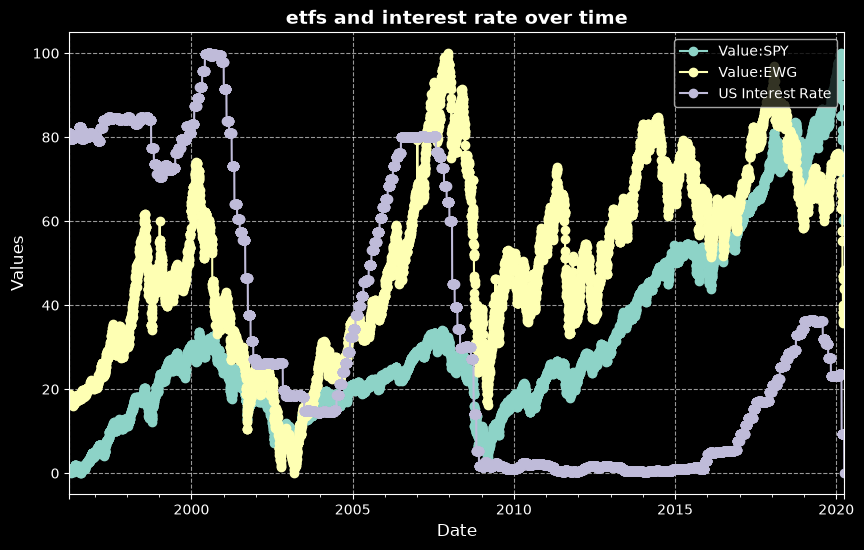

In [306]:
dataMerged_normalized = (dataMerged - dataMerged.min()) / (dataMerged.max() - dataMerged.min()) * 100

ax = dataMerged_normalized.plot(figsize=(10, 6), marker="o")

# 3. Customize the plot using Matplotlib
plt.title("etfs and interest rate over time", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)


In [307]:
def GrangerCausation_interestRate(data, grangerLag = [2] ,columnInterestRate="US Interest Rate"):
    df_interestRate = data[columnInterestRate]
    df = data.drop(columns=[columnInterestRate])

    df_output = pd.DataFrame(np.zeros((len(grangerLag),len(df.columns))),index=grangerLag, columns=df.columns)
    df_output.index.name = 'Lag in days'
    for etf in df.columns:
        data_etf = df[etf]

        data = pd.concat([data_etf,df_interestRate],axis=1, join="inner")
        grangerCause = grangercausalitytests(data , grangerLag, verbose=False)

        #grangerCausal_p_values = [round(grangerCause[i+1][0]['params_ftest'][1],4) for i in range(len(grangerLag))]
        #grangerCausal_p_value = np.average(grangerCausal_p_values)
        #print("ETF: " + etf + "  "+ str(grangerCausal_p_value))

        for lag in grangerLag:

            p_value = grangerCause[lag][0]["ssr_ftest"][0]
            df_output.loc[lag,etf] = p_value


    #print as table
    print(df_output)


    ax = df_output.plot(figsize=(10, 6), marker="o")
    plt.title("P value of etfs over different lag ranges", fontsize=14, fontweight="bold")
    plt.xlabel("Lag value", fontsize=12)
    plt.ylabel("P alues", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)

MDY = S&P MidCap 400
SPY = S&P 500
XLF = Financial Select Sector
EWG = Germany ETF
CEF = CEF Income Composite ETF 
             Value:SPY  Value:EWG
Lag in days                      
1             0.222944   0.023821
2             2.543396   1.725495
3             1.743805   1.423935
5             2.797735   1.952462
10            7.970231   3.675650
20            8.028641   4.051413
40            6.605640   3.431165
100           3.486059   2.105184
200           2.151926   1.728977
500           1.412052   1.558137


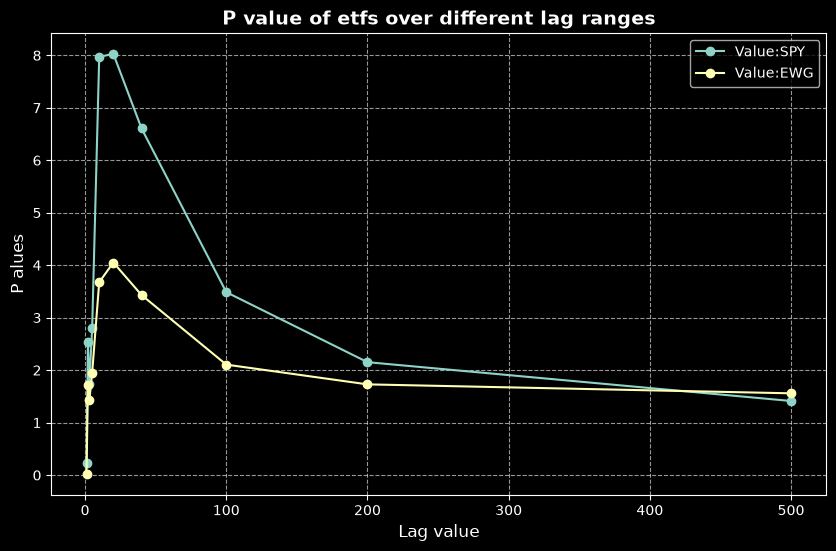

In [308]:
print(message)
GrangerCausation_interest~~~~Rate(data=dataMerged,grangerLag = [1,2,3,5,10,20,40,100,200,500])